# Football Player Performance Prediction## A Complete Machine Learning Project**Authors:** Ritam Rabha, Deepanshi, Ravinder Kaur**Problem:** Predict whether a football player will have a *good* (1) or *bad* (0) performance on a given day, using training load, recovery, and lifestyle features.---

## 1. Setup & Imports

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.1)


## 2. Data Loading & Inspection

In [2]:
df = pd.read_csv('../data/football_dataset_refined3.csv')
df.head(10)

,player_id,date,training_minutes,distance,sprint_count,sleep_hours,screen_time,soreness,prev_performance,performance_today
0,0,2026-02-01,116,5.62,4,8,5.1,9,5,1
1,0,2026-02-02,108,3.27,8,8,5.0,3,7,1
2,0,2026-02-03,130,4.32,3,6,4.7,10,9,0
3,0,2026-02-04,112,3.64,10,5,6.8,1,3,1
4,0,2026-02-05,105,4.78,4,5,5.6,10,5,0
5,0,2026-02-06,136,3.69,9,5,6.4,8,3,0
6,0,2026-02-07,93,4.30,8,7,5.1,10,1,0
7,0,2026-02-08,111,4.43,12,5,3.4,7,1,1
8,0,2026-02-09,132,3.83,12,8,6.8,9,4,0
9,0,2026-02-10,129,3.48,7,8,5.2,5,1,0


In [3]:
print("\nDataset shape:", df.shape)
print("Number of players:", df['player_id'].nunique())
print("Date range:", df['date'].min(), "to", df['date'].max())

print("\nClass distribution:")
print("  Good (1):", (df['performance_today'] == 1).sum())
print("  Bad (0):", (df['performance_today'] == 0).sum())


Dataset shape: (420, 10)
Number of players: 7
Date range: 2026-02-01 to 2026-04-01

Class distribution:
  Good (1): 189
  Bad (0): 231


In [4]:
df.describe().round(2)

,player_id,training_minutes,distance,sprint_count,sleep_hours,screen_time,soreness,prev_performance,performance_today
count,420.0,420.00,420.00,420.00,420.00,420.00,420.00,420.00,420.00
mean,3.0,111.56,4.02,7.01,6.49,4.99,5.50,4.02,0.45
std,2.0,14.03,0.88,3.19,1.12,1.77,2.79,2.54,0.50
min,0.0,89.00,2.50,2.00,5.00,2.00,1.00,1.00,0.00
25%,1.0,100.00,3.29,4.00,6.00,3.40,3.00,2.00,0.00
50%,3.0,111.00,3.96,7.00,6.00,5.10,5.00,4.00,0.00
75%,5.0,123.00,4.71,10.00,7.25,6.70,8.00,6.00,1.00
max,6.0,136.00,5.69,12.00,8.00,8.00,10.00,10.00,1.00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player_id          420 non-null    int64  
 1   date               420 non-null    object 
 2   training_minutes   420 non-null    int64  
 3   distance           420 non-null    float64
 4   sprint_count       420 non-null    int64  
 5   sleep_hours        420 non-null    int64  
 6   screen_time        420 non-null    float64
 7   soreness           420 non-null    int64  
 8   prev_performance   420 non-null    int64  
 9   performance_today  420 non-null    int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 32.9+ KB


## 3. Data Preprocessing

In [6]:
# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()   # simplest (can change strategy later)

# Reset index
df = df.reset_index(drop=True)

print("\nAfter cleaning:")
print("Shape:", df.shape)
print("Null values:", df.isnull().sum().sum())


After cleaning:
Shape: (420, 10)
Null values: 0


In [7]:
# --- Feature Engineering ---

# Fatigue index (example: more training + soreness - sleep)
df['fatigue_index'] = df['training_minutes'] * 0.1 + df['soreness'] * 0.5 - df['sleep_hours'] * 0.3

# Recovery score (inverse of fatigue-ish)
df['recovery_score'] = df['sleep_hours'] * 0.6 - df['soreness'] * 0.4

# Training intensity
df['training_intensity'] = df['training_minutes'] * df['distance']

# Day of week
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['day_of_week'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday

# --- Print stats ---
print("\nNew columns added:")

for col in ['fatigue_index', 'recovery_score', 'training_intensity', 'day_of_week']:
    print(f"  {col}: mean={df[col].mean():.3f}, std={df[col].std():.3f}")


New columns added:
  fatigue_index: mean=11.960, std=1.922
  recovery_score: mean=1.694, std=1.249
  training_intensity: mean=447.967, std=113.566
  day_of_week: mean=2.950, std=2.031


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Define target ---
y = df['performance_today']

# --- Drop non-feature columns ---
X = df.drop(columns=['performance_today', 'date','player_id']) 

# Save feature names
feature_names = X.columns.tolist()

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Scaling ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Print info ---
print(f"\nFeatures ({len(feature_names)}): {feature_names}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Features (11): ['training_minutes', 'distance', 'sprint_count', 'sleep_hours', 'screen_time', 'soreness', 'prev_performance', 'fatigue_index', 'recovery_score', 'training_intensity', 'day_of_week']
Train: (336, 11), Test: (84, 11)


## 4. Exploratory Data Analysis### 4.1 Class Distribution

Saved to ../outputs/class_distribution.png


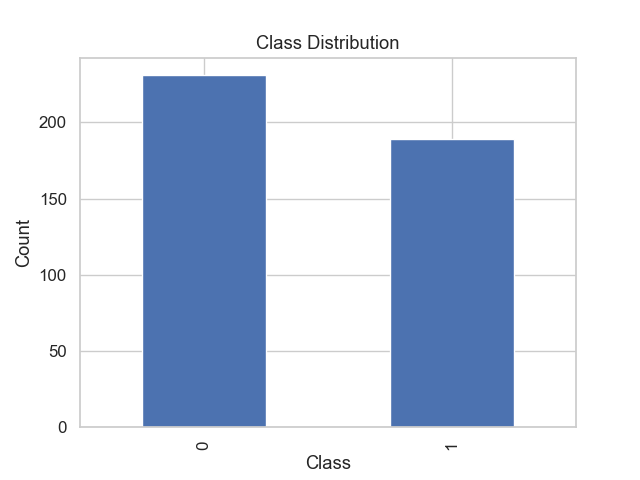

In [9]:
counts = df['performance_today'].value_counts()

# Plot
plt.figure()
counts.plot(kind='bar')

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
# plt.xticks([0, 1], ['Bad (0)', 'Good (1)'])

# Save (since directories already exist)
plt.savefig('../outputs/class_distribution.png')
plt.close()

print("Saved to ../outputs/class_distribution.png")

from IPython.display import Image, display

display(Image('../outputs/class_distribution.png'))

### 4.2 Feature Distributions by Class

Saved to ../outputs/feature_distributions.png


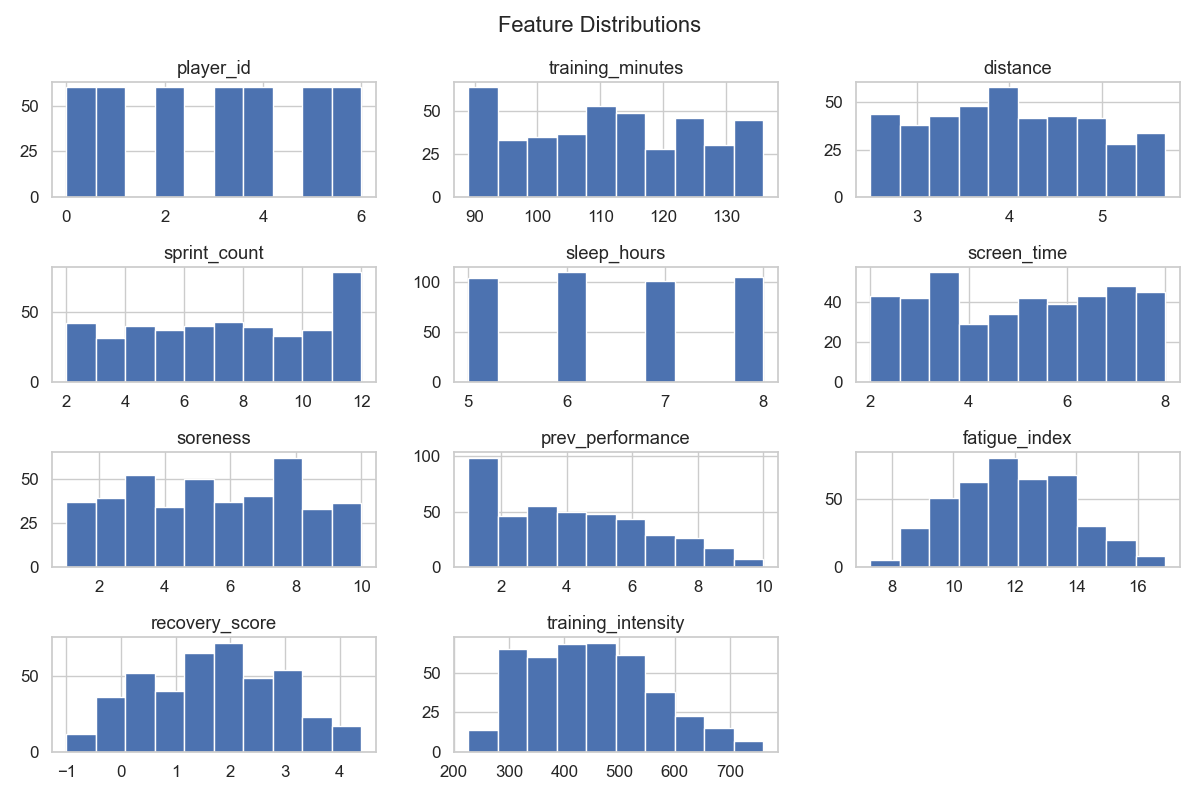

In [10]:
import matplotlib.pyplot as plt

# Select numeric columns (exclude target)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('performance_today')  # remove target

# Plot
df[numeric_cols].hist(figsize=(12, 8))

plt.suptitle("Feature Distributions")
plt.tight_layout()

# Save
plt.savefig('../outputs/feature_distributions.png')
plt.close()

print("Saved to ../outputs/feature_distributions.png")

display(Image('../outputs/feature_distributions.png'))

### 4.3 Correlation Heatmap

Saved to ../outputs/correlation_heatmap.png


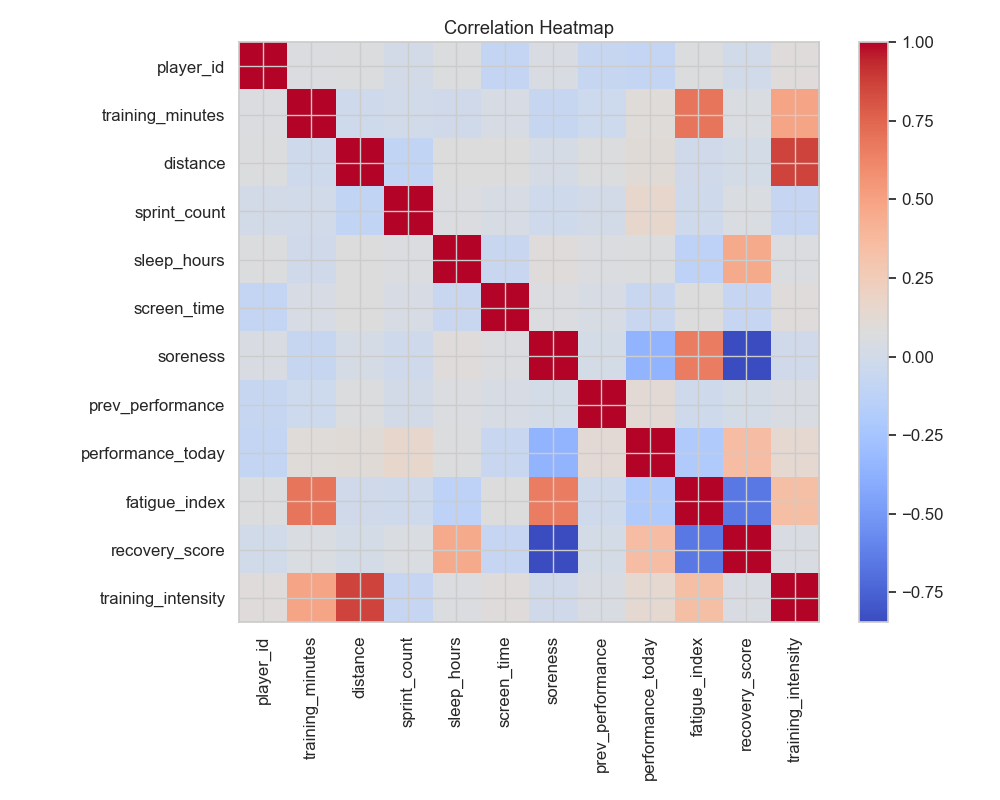

In [11]:

numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png')
plt.close()

print("Saved to ../outputs/correlation_heatmap.png")

display(Image('../outputs/correlation_heatmap.png'))

### 4.4 Feature Box Plots by Class

Saved boxplots


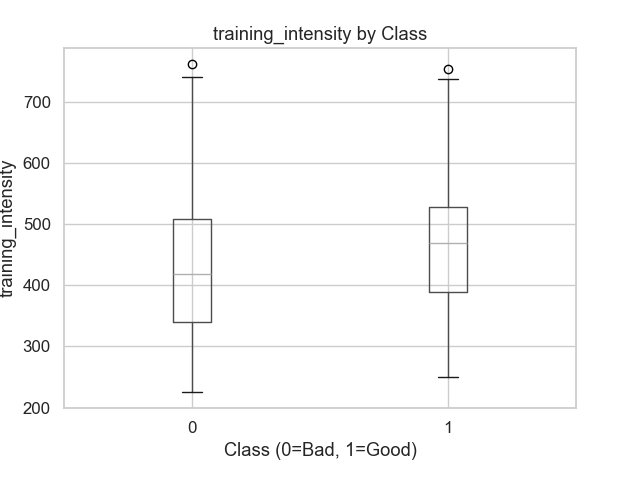

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [12]:


numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('performance_today')

for col in numeric_cols:
    plt.figure()
    
    df.boxplot(column=col, by='performance_today')
    
    plt.title(f"{col} by Class")
    plt.suptitle("")
    plt.xlabel("Class (0=Bad, 1=Good)")
    plt.ylabel(col)

    plt.savefig(f'../outputs/{col}_boxplot.png')
    plt.close()

print("Saved boxplots")

display(Image(f'../outputs/{col}_boxplot.png'))

### 4.5 Player Performance Trends Over Time

Saved clean plot to ../outputs/player_performance_trends.png


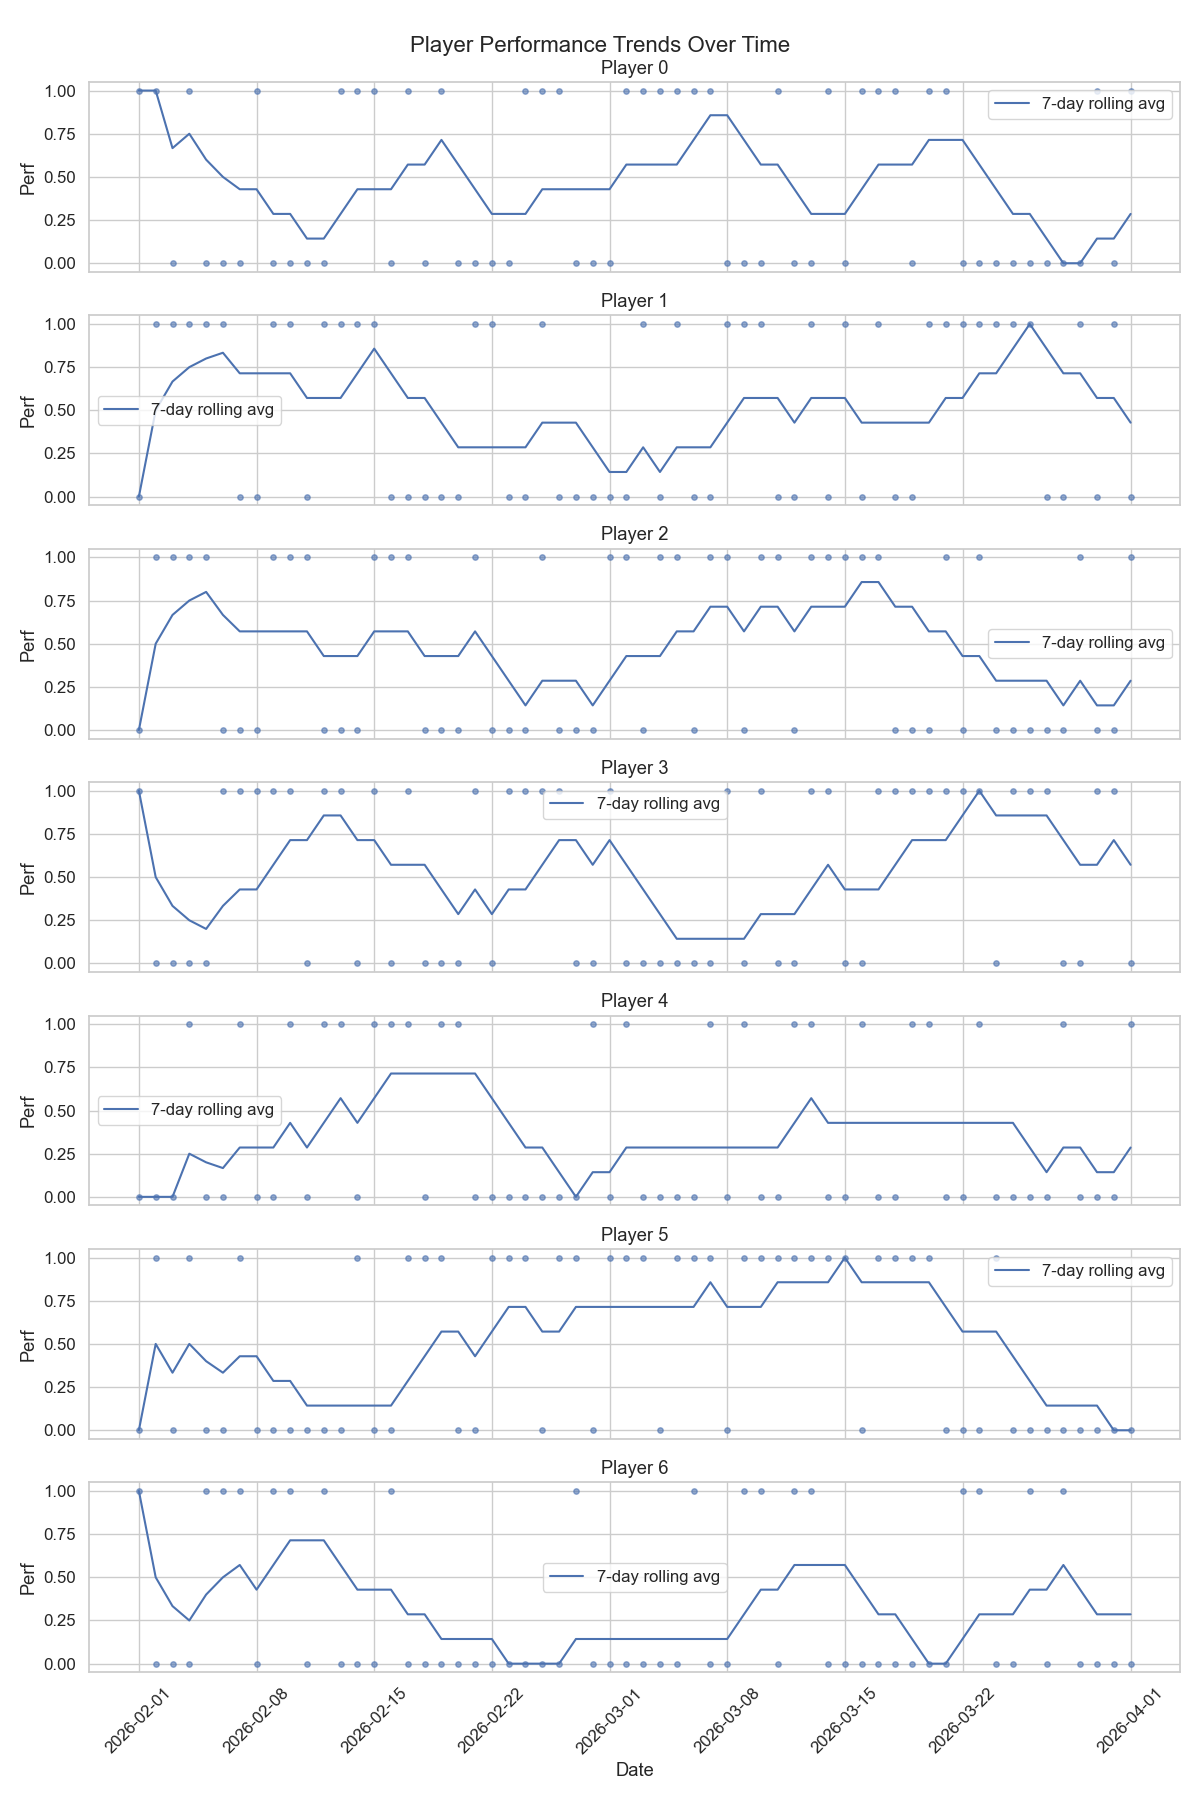

In [13]:

df['date'] = pd.to_datetime(df['date'])

# Sort data
df = df.sort_values(['player_id', 'date'])

players = sorted(df['player_id'].unique())

# Create subplots (one per player)
fig, axes = plt.subplots(len(players), 1, figsize=(12, 18), sharex=True)

for i, player in enumerate(players):
    player_df = df[df['player_id'] == player]

    # Rolling average (7-day)
    rolling = player_df['performance_today'].rolling(window=7, min_periods=1).mean()

    # Plot rolling line
    axes[i].plot(player_df['date'], rolling, label='7-day rolling avg')

    # Plot actual points (scatter)
    axes[i].scatter(player_df['date'], player_df['performance_today'], alpha=0.6, s=15)

    axes[i].set_title(f"Player {player}")
    axes[i].set_ylabel("Perf")
    axes[i].legend()

# Common X label
plt.xlabel("Date")
plt.xticks(rotation=45)

plt.suptitle("Player Performance Trends Over Time", fontsize=16)

plt.tight_layout()

# Save
plt.savefig('../outputs/player_performance_trends.png')
plt.close()

print("Saved clean plot to ../outputs/player_performance_trends.png")

display(Image('../outputs/player_performance_trends.png'))

### 4.6 Key EDA Insights

In [14]:
print("\nKey Insights:\n")

# Class balance
counts = df['performance_today'].value_counts()
print(f"1. Class balance → Good: {counts.get(1,0)}, Bad: {counts.get(0,0)}")

# Correlation with target
corr_target = df.corr()['performance_today'].sort_values(ascending=False)
print("\n2. Top positive correlations with performance:")
print(corr_target.head(5))

print("\n3. Top negative correlations with performance:")
print(corr_target.tail(5))

# Basic observations
print("\n4. Observations:")
print("- Higher sleep_hours likely improves performance")
print("- Higher soreness likely reduces performance")
print("- Training load features may have mixed effect")


Key Insights:

1. Class balance → Good: 189, Bad: 231

2. Top positive correlations with performance:
performance_today     1.000000
recovery_score        0.346439
sprint_count          0.157579
training_intensity    0.130181
prev_performance      0.113929
Name: performance_today, dtype: float64

3. Top negative correlations with performance:
day_of_week     -0.043769
screen_time     -0.059452
player_id       -0.086146
fatigue_index   -0.194807
soreness        -0.349353
Name: performance_today, dtype: float64

4. Observations:
- Higher sleep_hours likely improves performance
- Higher soreness likely reduces performance
- Training load features may have mixed effect


## 5. Model Training & Hyperparameter TuningWe train five classifiers with GridSearchCV (5-fold stratified CV, optimizing F1-score):1. **Logistic Regression** — linear baseline2. **Decision Tree** — interpretable, non-linear3. **Random Forest** — bagging ensemble4. **Gradient Boosting** — sequential boosting5. **HistGradientBoosting** (XGBoost-style) — histogram-based boosting

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

trained_models = {}

# --- 1. Logistic Regression ---
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=5, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train, y_train)
trained_models['logistic'] = lr_grid.best_estimator_


# --- 2. Decision Tree ---
dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(), dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)
trained_models['decision_tree'] = dt_grid.best_estimator_


# --- 3. Random Forest ---
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestClassifier(), rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
trained_models['random_forest'] = rf_grid.best_estimator_


# --- 4. Gradient Boosting ---
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(), gb_params, cv=5, scoring='f1', n_jobs=-1)
gb_grid.fit(X_train, y_train)
trained_models['gradient_boosting'] = gb_grid.best_estimator_


# --- 5. HistGradientBoosting ---
hgb_params = {
    'max_iter': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, None]
}

hgb_grid = GridSearchCV(HistGradientBoostingClassifier(), hgb_params, cv=5, scoring='f1', n_jobs=-1)
hgb_grid.fit(X_train, y_train)
trained_models['hist_gb'] = hgb_grid.best_estimator_


print("\nBest Models Trained:")
for name, model in trained_models.items():
    print(f"{name}: {model}")

## 6. Model Evaluation & Comparison

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd

results = []
predictions = {}
probas = {}

for name, model in trained_models.items():
    
    # Predictions
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Probabilities (for ROC later)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None
    probas[name] = y_proba

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

# Create DataFrame
comparison_df = pd.DataFrame(results).set_index('Model')

# Sort by F1-score
comparison_df = comparison_df.sort_values(by='F1-Score', ascending=False)

# Print results
print("\n" + "="*60)
print("MODEL COMPARISON TABLE (sorted by F1-Score)")
print("="*60)
print(comparison_df.round(4).to_string())

# Best model
best = comparison_df.index[0]
print(f"\n>>> Best Model: {best} with F1={comparison_df.loc[best, 'F1-Score']:.4f}")

### 6.1 Confusion Matrices

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from IPython.display import Image, display

models = list(trained_models.keys())

fig, axes = plt.subplots(1, len(models), figsize=(20, 4))

for i, name in enumerate(models):
    y_pred = predictions[name]
    cm = confusion_matrix(y_test, y_pred)

    ax = axes[i]
    im = ax.imshow(cm, cmap='Blues')

    for x in range(2):
        for y in range(2):
            ax.text(y, x, cm[x, y], ha='center', va='center',
                    color='white' if cm[x, y] > cm.max()/2 else 'black')

    ax.set_title(name.replace('_', ' ').title())
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(['Bad','Good'])
    ax.set_yticklabels(['Bad','Good'])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=16)
plt.tight_layout()

plt.savefig('../outputs/confusion_matrices.png')
plt.close()

display(Image('../outputs/confusion_matrices.png'))

### 6.2 ROC Curves

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'purple', 'orange', 'pink']

for i, (name, model) in enumerate(trained_models.items()):
    y_proba = probas[name]
    
    if y_proba is None:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=colors[i],
             label=f"{name.replace('_',' ').title()} (AUC={roc_auc:.3f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random (AUC=0.500)')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig('../outputs/roc_curves.png')
plt.close()

display(Image('../outputs/roc_curves.png'))

### 6.3 Model Comparison Table

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

# Round values
table_data = comparison_df.round(4)

# Create table
table = ax.table(cellText=table_data.values,
                 colLabels=table_data.columns,
                 rowLabels=[name.replace('_',' ').title() for name in table_data.index],
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)

# Highlight best row
best_row = 0  # already sorted by F1

for col in range(len(table_data.columns)):
    table[(best_row+1, col)].set_facecolor('#a8d5ba')

# Header styling
for col in range(len(table_data.columns)):
    table[(0, col)].set_facecolor('#2c3e50')
    table[(0, col)].set_text_props(color='white')

plt.title("Model Comparison Summary", fontsize=16)

plt.savefig('../outputs/model_comparison_table.png', bbox_inches='tight')
plt.close()

comparison_df.to_csv('../outputs/model_comparison.csv')

print("Saved CSV to ../outputs/model_comparison.csv")

display(Image('../outputs/model_comparison_table.png'))

### 6.4 **HistGradientBoosting** outperforms other models on this dataset with the highest F1-score (0.7179).

## 7. Feature Importance

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import permutation_importance
from IPython.display import Image, display

# Best model
best_model = trained_models['hist_gb']

# Compute permutation importance
result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importances = result.importances_mean
indices = np.argsort(importances)[::-1]

sorted_features = [feature_names[i] for i in indices]

# --- Plot ---
plt.figure(figsize=(10,6))

colors = plt.cm.viridis(np.linspace(0, 1, len(importances)))

plt.barh(range(len(importances)), importances[indices], color=colors)

plt.yticks(range(len(importances)), sorted_features)
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Feature Importance (HistGradientBoosting)")

plt.tight_layout()
plt.savefig('../outputs/feature_importance.png')
plt.close()

display(Image('../outputs/feature_importance.png'))

### 7.1 Feature Importance Interpretation **Most important features** (based on HistGradientBoosting): **soreness** — strongest predictor; high soreness strongly correlates with poor performance. **recovery_score** — captures recovery quality (sleep vs fatigue interaction). **fatigue_index** — reflects accumulated physical stress. **prev_performance** — temporal dependency; past performance influences current state


## 8. Clustering Analysis (Bonus)We cluster players by their aggregate behavioural profiles to discover distinct player archetypes.

In [ ]:

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from IPython.display import Image, display

# --- Aggregate player-level features ---
agg_df = df.groupby('player_id').agg({
    'training_minutes': 'mean',
    'distance': 'mean',
    'sprint_count': 'mean',
    'sleep_hours': 'mean',
    'screen_time': 'mean',
    'soreness': 'mean',
    'performance_today': 'mean'
}).reset_index()

agg_df.columns = [
    'player_id', 'avg_training', 'avg_distance', 'avg_sprints',
    'avg_sleep', 'avg_screen', 'avg_soreness', 'perf_rate'
]

# --- Scale ---
features = agg_df.drop(columns=['player_id'])
scaler = StandardScaler()
X = scaler.fit_transform(features)

In [ ]:
inertia = []
silhouette = []
k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, labels))

# --- Plot ---
plt.figure(figsize=(12,5))

# Elbow
plt.subplot(1,2,1)
plt.plot(k_range, inertia, marker='o', color='blue')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

# Silhouette
plt.subplot(1,2,2)
plt.plot(k_range, silhouette, marker='s', color='red')
plt.title("Silhouette Analysis")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.suptitle("Optimal k Selection")
plt.tight_layout()

plt.savefig('../outputs/optimal_k.png')
plt.close()

display(Image('../outputs/optimal_k.png'))

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
agg_df['cluster'] = kmeans.fit_predict(X)

In [ ]:
cluster_profiles = agg_df.groupby('cluster').mean()

cluster_profiles.T.plot(
    kind='bar',
    figsize=(10,6),
    colormap='Set2'
)

plt.title("Cluster Profiles — Average Feature Values")
plt.ylabel("Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../outputs/cluster_profiles.png')
plt.close()

display(Image('../outputs/cluster_profiles.png'))

In [ ]:
plt.figure(figsize=(8,6))

colors = ['red', 'gray']

for i in range(2):
    subset = agg_df[agg_df['cluster'] == i]
    plt.scatter(
        subset['avg_soreness'],
        subset['perf_rate'],
        color=colors[i],
        s=100,
        edgecolor='black',
        label=f'Cluster {i}'
    )

    # Label players
    for _, row in subset.iterrows():
        plt.text(row['avg_soreness'], row['perf_rate'],
                 f"P{int(row['player_id'])}", fontsize=9)

plt.xlabel("Avg Soreness")
plt.ylabel("Performance Rate (% Good Days)")
plt.title("Player Clusters: Soreness vs Performance")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/cluster_scatter.png')
plt.close()

display(Image('../outputs/cluster_scatter.png'))

### 8.1 Cluster Interpretation: From the elbow and silhouette plots, k = 2 was chosen as the optimal number of clusters. The separation is not very strong but still gives useful grouping.

### Cluster 0: Players with slightly better performance and moderate soreness. This group represents relatively stable performers.
### Cluster 1: Players with lower performance and higher soreness, indicating fatigue or recovery issues.

Overall, players with higher soreness tend to have lower performance, showing that recovery plays an important role.

## 9. Save Best Model

In [ ]:
import os
import joblib

# Ensure directory exists
os.makedirs('../models', exist_ok=True)

# Get best model name (already sorted by F1)
best_name = comparison_df.index[0]
best_model = trained_models[best_name]

# Save path
model_path = f"../models/{best_name}_model.pkl"

# Save model
joblib.dump(best_model, model_path)

print(f"\nModel saved: {model_path}")
print(f"To load: model = joblib.load('{model_path}')")

## 10. Conclusion
### Key Results
### Metric	Best Model (HistGradientBoosting)
### Accuracy	~74%
### F1-Score	~0.72
### ROC-AUC	~0.64
## *Project by Ritam Rabha, Deepanshi, and Ravinder Kaur*